In [1]:
import torch
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy import stats

# Path setup
src_dir = os.path.join(os.path.abspath(''), '..') 
configs_dir = os.path.join(os.path.abspath(''), '../..')
sys.path.insert(0, os.path.abspath(src_dir))
sys.path.insert(0, os.path.abspath(configs_dir))

from models.autoencoder import Autoencoder
from env.inventory import InventoryManagement, DemandDistribution
from configs.experiment_config import ExperimentConfig
from utils.generate_inventory_maps import DemandDistributionConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
from utils.data_loading import QMatrixData
from models.autoencoder import trainSAE, testSAE
from models.autoencoder import Autoencoder
import importlib
importlib.reload(sys.modules['models.autoencoder'])
import math as mt

num_channels = 10
kernel_dim = 2
states = 16
in_channels = 1
inventory_dim = 8
K = 5
lr = 5e-4
batch_size = 10
gamma_sparse = 1/20*mt.sqrt(16*in_channels/K)
train_epochs = 500

In [3]:
# 1. Setup Base Directory (adjust the '..' levels to match your project structure)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..')) 

train_dataset = QMatrixData(
    q_file_path=os.path.join(BASE_DIR, "data/inventory/q matrix dictionaries/q_matricestraining_4x4.pkl"),
    label_file_path=os.path.join(BASE_DIR, "data/inventory/label dictionaries/q_matrices_labelstraining_4x4.pkl")
)


autoencoder = Autoencoder(in_channels, inventory_dim, num_channels, kernel_dim, K)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=lr)

total_losses, recon_losses, sparsity_losses, all_messages = trainSAE(
    autoencoder, train_dataset, gamma_sparse, optimizer, batch_size, train_epochs, device
)

In [4]:
import models.autoencoder
importlib.reload(models.autoencoder)
import torch

# getting messages from trained language
_, _, _, all_messages, message_dict = testSAE(autoencoder, train_dataset, batch_size, gamma_sparse, device)

In [5]:
from configs.experiment_config import ExperimentConfig
# Import the specific helper functions from your teacher module
from rl.teacher import (
    generate_q_matrices, 
    make_inventory_env, 
    compute_perfect_qdict_inventory
)
from evaluation.student_eval import train_student, run_evaluations, run_evaluations_inventory
importlib.reload(sys.modules['rl.teacher'])
importlib.reload(sys.modules['evaluation.student_eval'])

config = ExperimentConfig()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Define where your data is stored (ensure this path exists)
data_dir = "../data/inventory"  # Adjust this path as needed

# 2. Pass the required arguments: make_env, compute_perfect_qdict, and data_dir
q_matrices, label_dict, wall_state_dict, sopt_dict = generate_q_matrices(
    config, 
    device, 
    make_inventory_env,              # The 'make_env' argument
    compute_perfect_qdict_inventory, # The 'compute_perfect_qdict' argument
    data_dir                         # The 'data_dir' argument
)

# Now call the student training with the compatible dictionary
student = train_student(
    label_dict, 
    wall_state_dict, 
    sopt_dict, 
    message_dict,
    config, 
    device, 
    make_inventory_env,
    num_eps=599
)

Computing Perfect Q-Dicts: 100%|██████████| 320/320 [00:00<00:00, 14048.33it/s]


Precomputing task environments...


Precomputing tasks: 100%|██████████| 320/320 [02:33<00:00,  2.09it/s]


Training student on 320 tasks...


Student epochs:   8%|▊         | 50/599 [00:20<03:46,  2.42it/s]

...

Student epochs:  83%|████████▎ | 500/599 [03:24<00:40,  2.45it/s]

    Epoch 500/599 complete


Student epochs:  92%|█████████▏| 550/599 [03:45<00:20,  2.35it/s]

    Epoch 550/599 complete


Student epochs: 100%|██████████| 599/599 [04:05<00:00,  2.44it/s]


In [6]:
importlib.reload(sys.modules['env.inventory'])
importlib.reload(sys.modules['evaluation.student_eval'])
from evaluation.student_eval import run_evaluations, run_evaluations_inventory

# Ensure all messages are on the correct device first to avoid mid-loop crashes
message_dict_device = {k: v.to(device) for k, v in message_dict.items()}

informed_rates, misinformed_rates = run_evaluations_inventory(
    student, 
    label_dict, 
    wall_state_dict, 
    message_dict_device,
    sopt_dict, 
    config, 
    device,
    make_inventory_env
)

Evaluating Inventory: 100%|██████████| 320/320 [02:47<00:00,  1.91it/s]

Informed Reward: -99.99 | Misinformed: -99.96


In [7]:
import evaluation.student_eval
importlib.reload(evaluation.student_eval)
from evaluation.student_eval import train_student_with_feedback

autoencoder, student = train_student_with_feedback(
    label_dict, 
    wall_state_dict, 
    sopt_dict, 
    q_matrices, 
    autoencoder, 
    student, 
    config, 
    device,
    make_inventory_env,
    n_transition_samples=200,
    num_eps=500
)

Precomputing task environments...


Precomputing tasks: 100%|██████████| 320/320 [02:41<00:00,  1.98it/s]


Joint training on 320 tasks...


Joint training epochs:  10%|█         | 50/500 [01:12<10:37,  1.42s/it]

    Epoch 50/500 completed


...

    Epoch 400/500 completed


Joint training epochs:  90%|█████████ | 450/500 [10:39<01:12,  1.45s/it]

    Epoch 450/500 completed


Joint training epochs: 100%|██████████| 500/500 [11:50<00:00,  1.42s/it]

    Epoch 500/500 completed


In [8]:
# Extract the optimized messages generated by the newly trained Autoencoder
message_dict_feedback = {}
autoencoder.eval()
with torch.no_grad():
    for task, (wall_label, init_state, goal_state, action_mode) in label_dict.items():
        q_mat = q_matrices[task].unsqueeze(0).to(device)
        message, _ = autoencoder(q_mat)
        message_dict_feedback[(wall_label, init_state, goal_state, action_mode)] = message.squeeze(0).detach()

In [9]:
informed_rates, misinformed_rates = run_evaluations_inventory(
    student, label_dict, wall_state_dict, message_dict_feedback, sopt_dict, config, device, make_inventory_env
)

Evaluating Inventory: 100%|██████████| 320/320 [02:44<00:00,  1.94it/s]

Informed Reward: -99.87 | Misinformed: -99.88


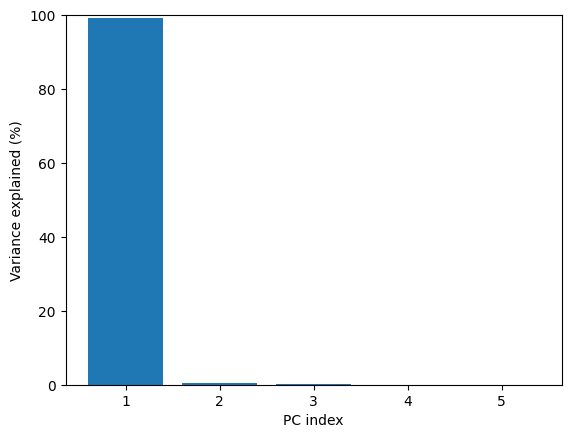

ValueError: 'c' argument has 225 elements, which is inconsistent with 'x' and 'y' with size 320.

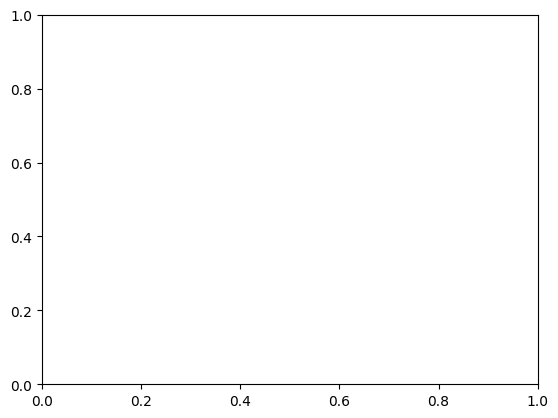

In [10]:
from sklearn.decomposition import PCA
from utils.plotting import plot_pca_variance, plot_pca_by_label

# Stack all messages into a single tensor
messages = torch.cat(all_messages, dim=0)  # shape: (num_tasks, K)
messages_np = messages.numpy()

wall_labels = [train_dataset.labels[i][0] for i in range(225)]
goal_labels = [train_dataset.labels[i][2] for i in range(225)]

pca = PCA(n_components=5)
pca_result = pca.fit_transform(messages_np)

# get plots
plot_pca_variance(pca)
plot_pca_by_label(pca_result, wall_labels, "color: wall position")
plot_pca_by_label(pca_result, goal_labels, "color: goal labels")

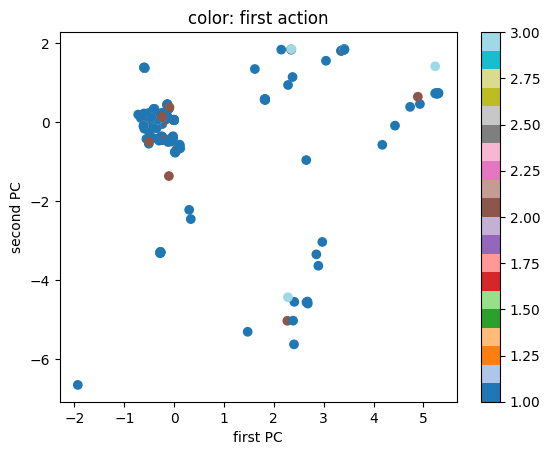

In [ ]:
first_actions = []
for i in sorted_tasks:
    wall_index, init_state, goal_state, demand = train_label_dict[i]
    q_matrix = q_matrices[i]
    indx, indy = init_state // config.grid_dim, init_state % config.grid_dim
    first_action = q_matrix[:, indx, indy].argmax().item()
    first_actions.append(first_action)

plot_pca_by_label(pca_result, first_actions, "color: first action")